TASK-1

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

In [2]:

TRAIN_DIR = "train/train"
TEST_DIR = "test/test"
LABEL_FILE = "trainLabels.csv"

In [3]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [4]:
labels_df = pd.read_csv(LABEL_FILE)

print(labels_df.head())
print("\nShape:", labels_df.shape)

   id       label
0   1        frog
1   2       truck
2   3       truck
3   4        deer
4   5  automobile

Shape: (50000, 2)


In [5]:
label_to_index = {
    name: i for i, name in enumerate(class_names)
}

print(label_to_index)

{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


In [6]:
X_train = []
y_train = []

for _, row in labels_df.iterrows():

    image_id = row["id"]
    label = row["label"]

    image_path = os.path.join(
        TRAIN_DIR,
        f"{image_id}.png"
    )

    image = Image.open(image_path)

    X_train.append(np.array(image))
    y_train.append(label_to_index[label])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [8]:
print("\nImage shape:", X_train.shape)
print("Label shape:", y_train.shape)


Image shape: (50000, 32, 32, 3)
Label shape: (50000,)


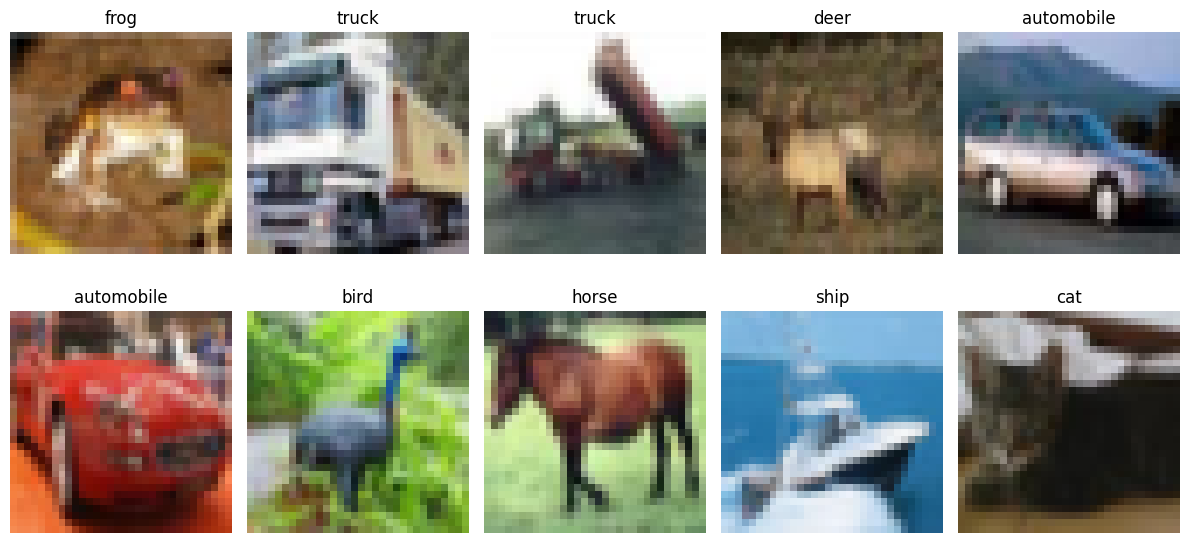

In [9]:
plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

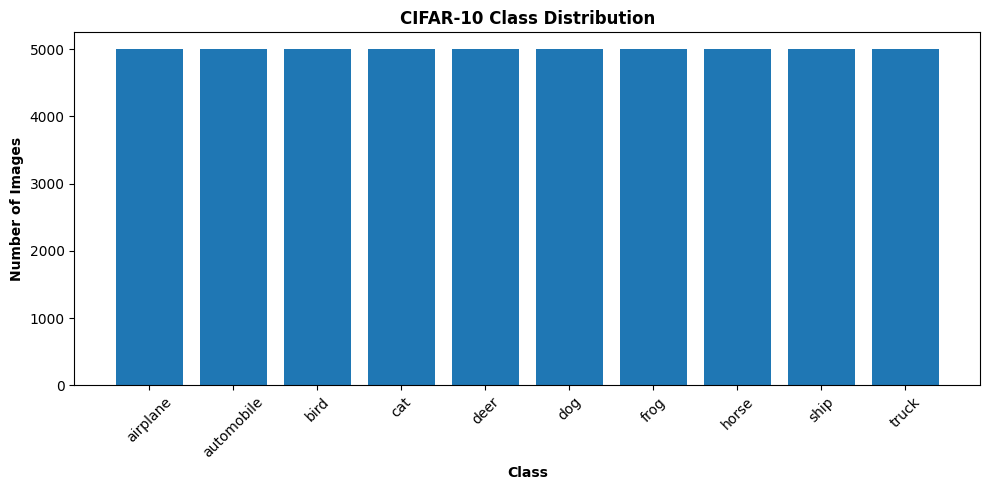

In [10]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))

plt.bar(
    [class_names[i] for i in unique],
    counts
)

plt.xlabel("Class", fontweight="bold")
plt.ylabel("Number of Images", fontweight="bold")
plt.title("CIFAR-10 Class Distribution", fontweight="bold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

TASK-2

In [11]:
def convolution(image, kernel):
    """
    Perform 2D convolution on a single-channel image.
    Uses stride = 1 and valid padding.
    """

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):

            region = image[
                i:i + kernel_height,
                j:j + kernel_width
            ]

            output[i, j] = np.sum(region * kernel)

    return output

In [12]:
image = X_train[0]

gray_image = np.mean(image, axis=2)

In [13]:
kernel_3 = np.ones((3, 3)) / 9
kernel_5 = np.ones((5, 5)) / 25
kernel_7 = np.ones((7, 7)) / 49

In [14]:
feature_3 = convolution(gray_image, kernel_3)
feature_5 = convolution(gray_image, kernel_5)
feature_7 = convolution(gray_image, kernel_7)

In [15]:
print("Original image :", gray_image.shape)

print("3 × 3 feature map:", feature_3.shape)
print("5 × 5 feature map:", feature_5.shape)
print("7 × 7 feature map:", feature_7.shape)

Original image : (32, 32)
3 × 3 feature map: (30, 30)
5 × 5 feature map: (28, 28)
7 × 7 feature map: (26, 26)


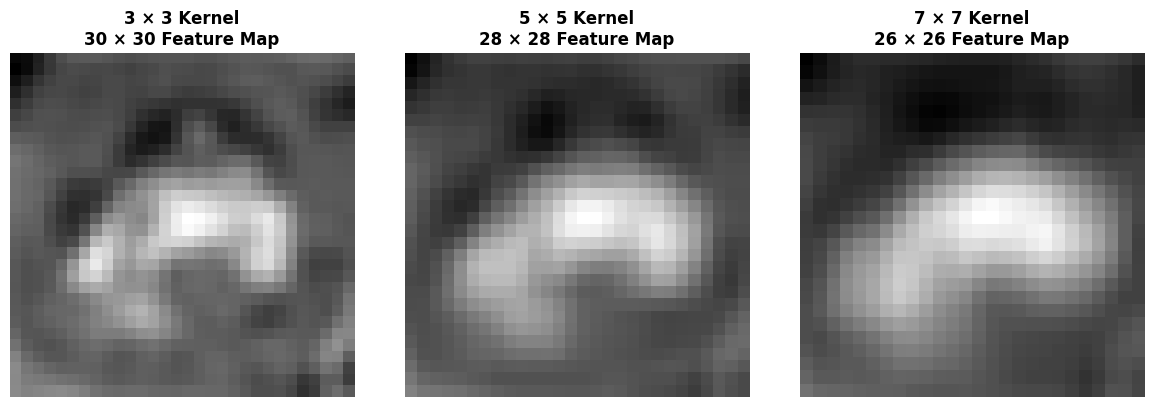

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(feature_3, cmap="gray")
plt.title("3 × 3 Kernel\n30 × 30 Feature Map", fontweight="bold")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(feature_5, cmap="gray")
plt.title("5 × 5 Kernel\n28 × 28 Feature Map", fontweight="bold")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(feature_7, cmap="gray")
plt.title("7 × 7 Kernel\n26 × 26 Feature Map", fontweight="bold")
plt.axis("off")

plt.tight_layout()
plt.show()

Task-3

In [17]:
def convolution_with_stride(image, kernel, stride=1, padding=0):

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Add zero padding
    padded_image = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode="constant"
    )

    padded_height, padded_width = padded_image.shape

    output_height = (
        (padded_height - kernel_height) // stride
    ) + 1

    output_width = (
        (padded_width - kernel_width) // stride
    ) + 1

    output = np.zeros(
        (output_height, output_width)
    )

    for i in range(output_height):
        for j in range(output_width):

            row_start = i * stride
            col_start = j * stride

            region = padded_image[
                row_start:row_start + kernel_height,
                col_start:col_start + kernel_width
            ]

            output[i, j] = np.sum(region * kernel)

    return output

In [18]:
kernel = np.ones((3, 3)) / 9

In [19]:
output_stride1 = convolution_with_stride(
    gray_image,
    kernel,
    stride=1,
    padding=0
)

print("Stride = 1:", output_stride1.shape)

Stride = 1: (30, 30)


In [20]:
output_stride2 = convolution_with_stride(
    gray_image,
    kernel,
    stride=2,
    padding=0
)

print("Stride = 2:", output_stride2.shape)

Stride = 2: (15, 15)


In [21]:
output_valid = convolution_with_stride(
    gray_image,
    kernel,
    stride=1,
    padding=0
)

print("Valid padding:", output_valid.shape)

Valid padding: (30, 30)


In [22]:
output_same = convolution_with_stride(
    gray_image,
    kernel,
    stride=1,
    padding=1
)

print("Same padding:", output_same.shape)

Same padding: (32, 32)


In [23]:
print("\n--- Stride and Padding Comparison ---")

print("Stride = 1, Valid :", output_stride1.shape)
print("Stride = 2, Valid :", output_stride2.shape)
print("Stride = 1, Same  :", output_same.shape)


--- Stride and Padding Comparison ---
Stride = 1, Valid : (30, 30)
Stride = 2, Valid : (15, 15)
Stride = 1, Same  : (32, 32)


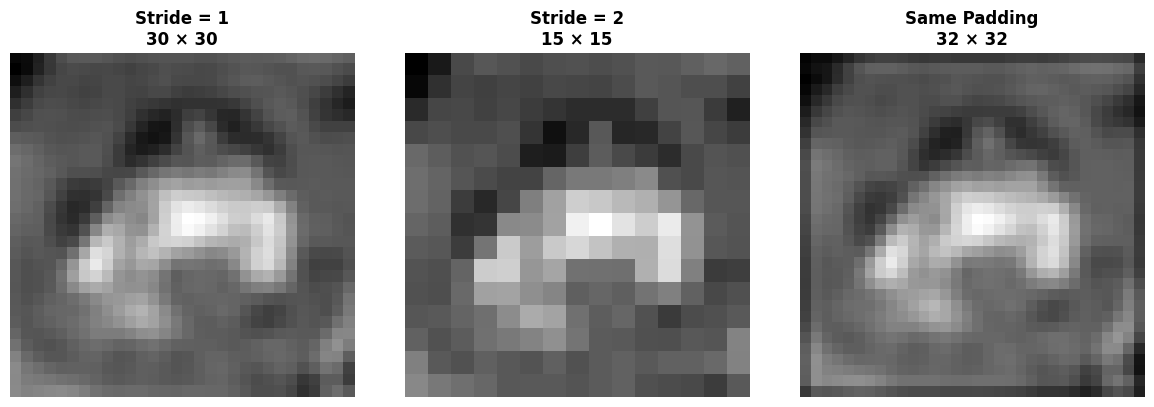

In [24]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(output_stride1, cmap="gray")
plt.title("Stride = 1\n30 × 30", fontweight="bold")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(output_stride2, cmap="gray")
plt.title("Stride = 2\n15 × 15", fontweight="bold")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(output_same, cmap="gray")
plt.title("Same Padding\n32 × 32", fontweight="bold")
plt.axis("off")

plt.tight_layout()
plt.show()

Task-4

In [26]:
sample_image = X_train[0]
print("Sample image shape:", sample_image.shape)

Sample image shape: (32, 32, 3)


In [27]:
sample_image = sample_image.astype("float32") / 255.0

In [28]:
sample_input = np.expand_dims(sample_image, axis=0)
print("Input shape:", sample_input.shape)

Input shape: (1, 32, 32, 3)


In [29]:
conv_layer = tf.keras.layers.Conv2D(
    filters=8,
    kernel_size=(3, 3),
    strides=1,
    padding="same",
    activation="relu"
)

In [30]:
feature_maps = conv_layer(sample_input)
print("Feature map shape:", feature_maps.shape)

Feature map shape: (1, 32, 32, 8)


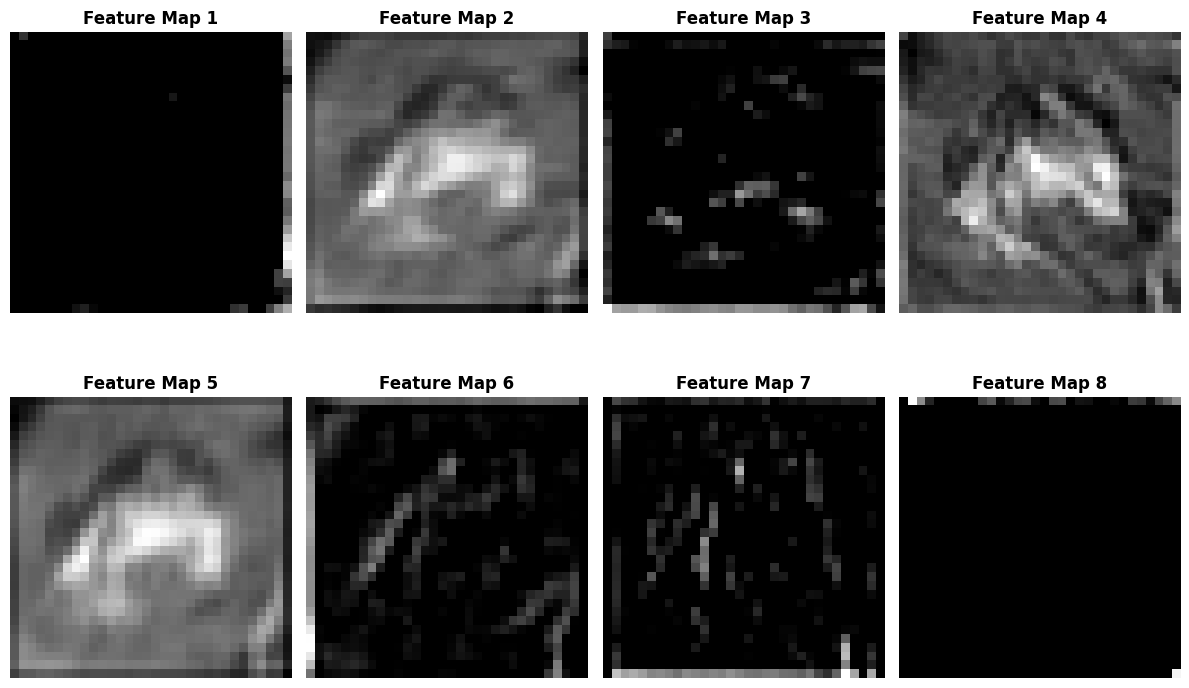

In [31]:
plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(feature_maps[0, :, :, i], cmap="gray")

    plt.title(
        f"Feature Map {i + 1}",
        fontweight="bold"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

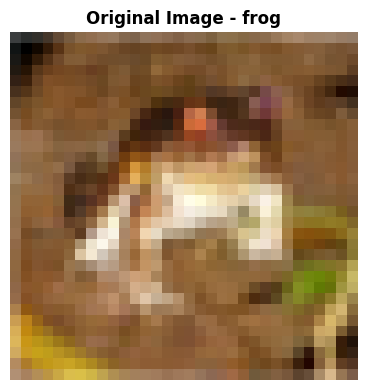

In [33]:
plt.figure(figsize=(4, 4))

plt.imshow(sample_image)

plt.title(
    f"Original Image - {class_names[y_train[0]]}",
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()

Task-5

In [34]:
max_pool = tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=2
)

avg_pool = tf.keras.layers.AveragePooling2D(
    pool_size=(2, 2),
    strides=2
)

In [35]:
feature_maps

<tf.Tensor: shape=(1, 32, 32, 8), dtype=float32, numpy=
array([[[[0.        , 0.07793679, 0.0944437 , ..., 0.05479919,
          0.        , 0.        ],
         [0.07319088, 0.06776269, 0.        , ..., 0.07117209,
          0.08172504, 0.07839556],
         [0.        , 0.05713888, 0.        , ..., 0.11129291,
          0.05734983, 0.04305173],
         ...,
         [0.        , 0.3725917 , 0.        , ..., 0.20462869,
          0.03653909, 0.02078556],
         [0.        , 0.3485562 , 0.        , ..., 0.20452416,
          0.05109386, 0.03050606],
         [0.23506498, 0.20274873, 0.        , ..., 0.05208214,
          0.        , 0.04169543]],

        [[0.        , 0.07857272, 0.07342216, ..., 0.05176937,
          0.        , 0.        ],
         [0.        , 0.10634908, 0.0459789 , ..., 0.        ,
          0.00494394, 0.        ],
         [0.        , 0.14547901, 0.03862711, ..., 0.01087492,
          0.        , 0.        ],
         ...,
         [0.        , 0.43513486

In [36]:
max_pooled = max_pool(feature_maps)
avg_pooled = avg_pool(feature_maps)

In [37]:
print("Original feature maps :", feature_maps.shape)
print("Max pooling output    :", max_pooled.shape)
print("Average pooling output:", avg_pooled.shape)

Original feature maps : (1, 32, 32, 8)
Max pooling output    : (1, 16, 16, 8)
Average pooling output: (1, 16, 16, 8)


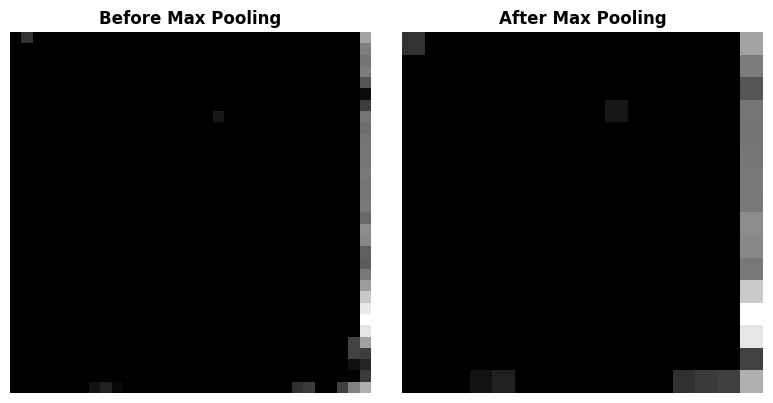

In [38]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)

plt.imshow(
    feature_maps[0, :, :, 0],
    cmap="gray"
)

plt.title(
    "Before Max Pooling",
    fontweight="bold"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    max_pooled[0, :, :, 0],
    cmap="gray"
)

plt.title(
    "After Max Pooling",
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()
plt.show()

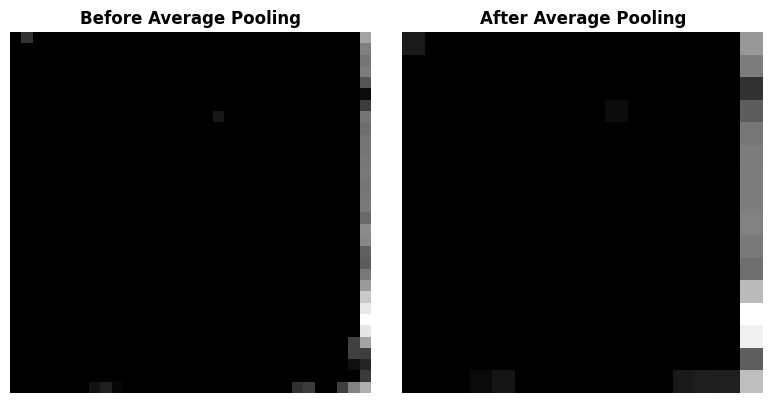

In [39]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)

plt.imshow(
    feature_maps[0, :, :, 0],
    cmap="gray"
)

plt.title(
    "Before Average Pooling",
    fontweight="bold"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    avg_pooled[0, :, :, 0],
    cmap="gray"
)

plt.title(
    "After Average Pooling",
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()
plt.show()

Task-6

In [40]:
from sklearn.model_selection import train_test_split

In [42]:
X_train = X_train.astype("float32") / 255.0

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [45]:
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels :", y_test.shape)

Training data: (40000, 32, 32, 3)
Testing data : (10000, 32, 32, 3)
Training labels: (40000,)
Testing labels : (10000,)


In [46]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

In [47]:
model = Sequential([
    
    Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        10,
        activation="softmax"
    )
])

c:\Users\karet\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [50]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4832 - loss: 1.4387 - val_accuracy: 0.5918 - val_loss: 1.1845
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.6248 - loss: 1.0657 - val_accuracy: 0.6223 - val_loss: 1.0520
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.6784 - loss: 0.9113 - val_accuracy: 0.6580 - val_loss: 0.9958
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7151 - loss: 0.8057 - val_accuracy: 0.6770 - val_loss: 0.9452
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7482 - loss: 0.7070 - val_accuracy: 0.6765 - val_loss: 0.9296
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7821 - loss: 0.6142 - val_accuracy: 0.6977 - val_loss: 0.9243
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8127 - loss: 0.5321 - val_accuracy: 0.6915 - val_loss: 0.9484
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8372 - l

In [51]:
model.save("cifar10_cnn.keras")

In [52]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


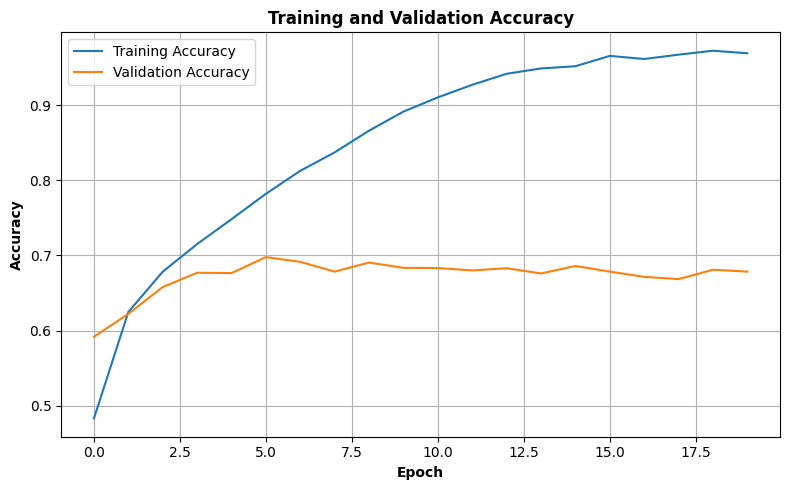

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Accuracy", fontweight="bold")
plt.title("Training and Validation Accuracy", fontweight="bold")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

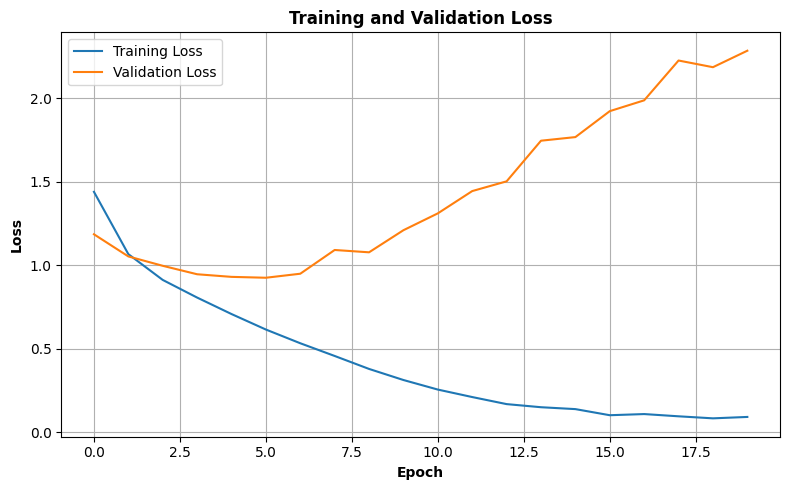

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Loss", fontweight="bold")
plt.title("Training and Validation Loss", fontweight="bold")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Task-7

In [55]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6703 - loss: 2.2873
Test Loss     : 2.28725266456604
Test Accuracy : 0.6703000068664551


In [56]:
y_probability = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [57]:
print("Predicted labels:", y_pred.shape)
print("Actual labels   :", y_test.shape)

Predicted labels: (10000,)
Actual labels   : (10000,)


In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\n--- Test Performance ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


--- Test Performance ---
Accuracy  : 0.6703
Precision : 0.6718
Recall    : 0.6703
F1-score  : 0.6697


In [59]:
from sklearn.metrics import classification_report

print("\n--- Classification Report ---")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)


--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.72      0.70      0.71      1000
  automobile       0.78      0.78      0.78      1000
        bird       0.63      0.49      0.55      1000
         cat       0.48      0.48      0.48      1000
        deer       0.58      0.66      0.62      1000
         dog       0.55      0.58      0.57      1000
        frog       0.72      0.76      0.74      1000
       horse       0.70      0.71      0.70      1000
        ship       0.81      0.79      0.80      1000
       truck       0.75      0.76      0.75      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.67      0.67      0.67     10000



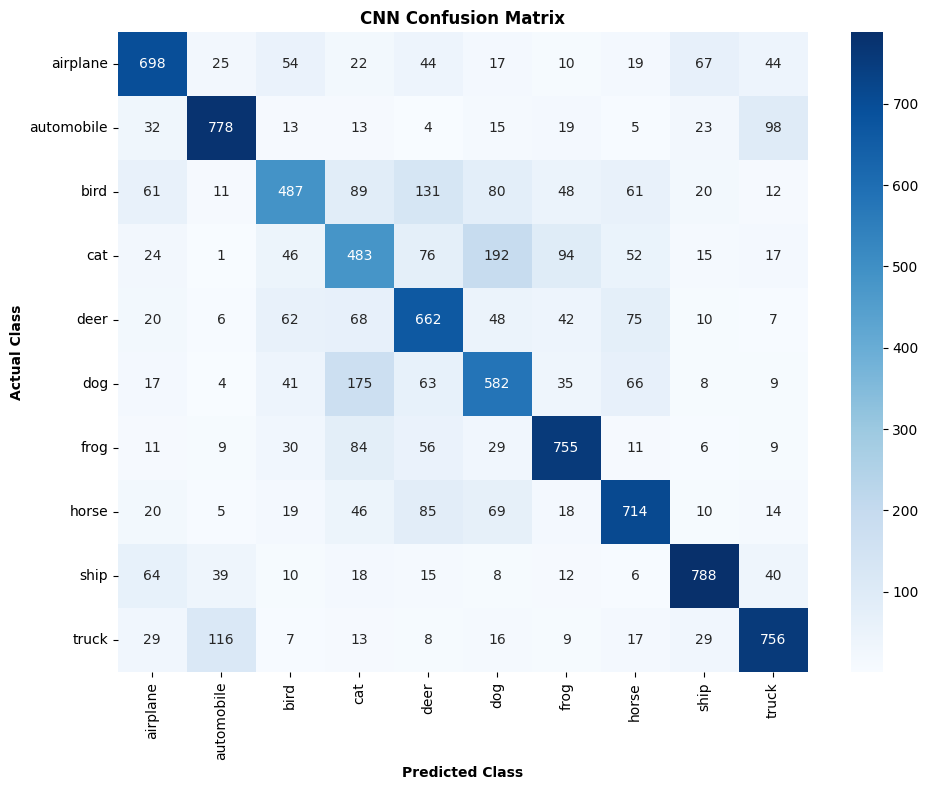

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel(
    "Predicted Class",
    fontweight="bold"
)

plt.ylabel(
    "Actual Class",
    fontweight="bold"
)

plt.title(
    "CNN Confusion Matrix",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [61]:
plt.savefig(
    "confusion_matrix.png",
    dpi=600,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Task-8

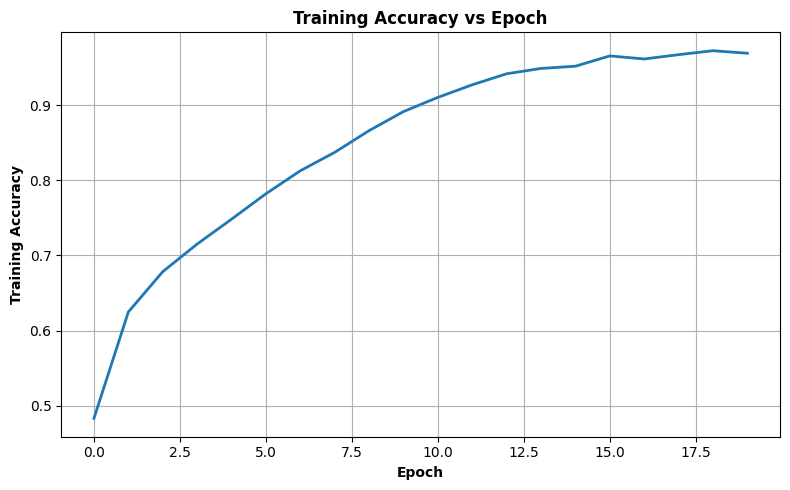

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    linewidth=2
)

plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Training Accuracy", fontweight="bold")
plt.title("Training Accuracy vs Epoch", fontweight="bold")

plt.grid(True)
plt.tight_layout()
plt.show()

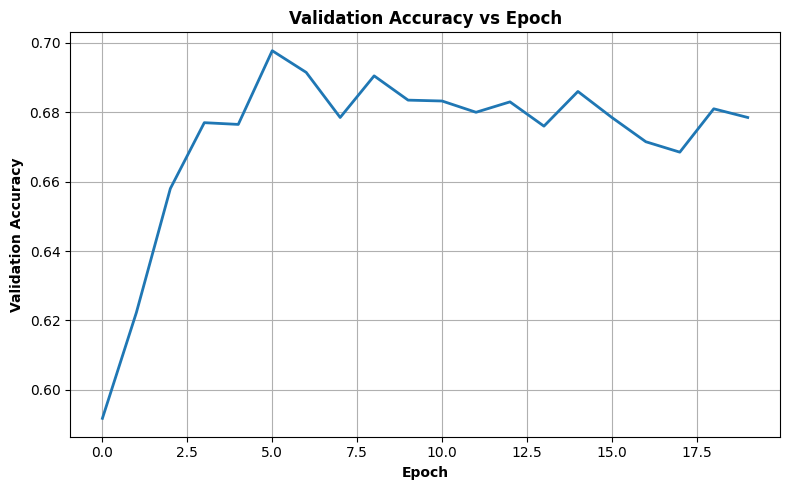

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_accuracy"],
    linewidth=2
)

plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Validation Accuracy", fontweight="bold")
plt.title("Validation Accuracy vs Epoch", fontweight="bold")

plt.grid(True)
plt.tight_layout()
plt.show()

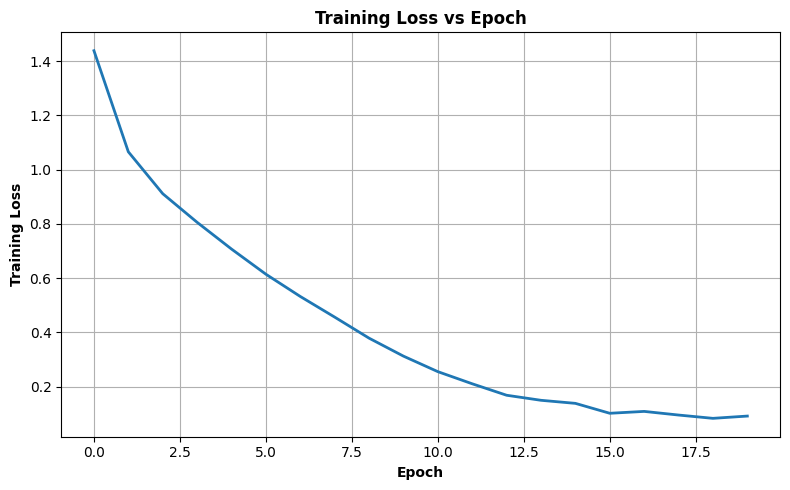

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    linewidth=2
)

plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Training Loss", fontweight="bold")
plt.title("Training Loss vs Epoch", fontweight="bold")

plt.grid(True)
plt.tight_layout()
plt.show()

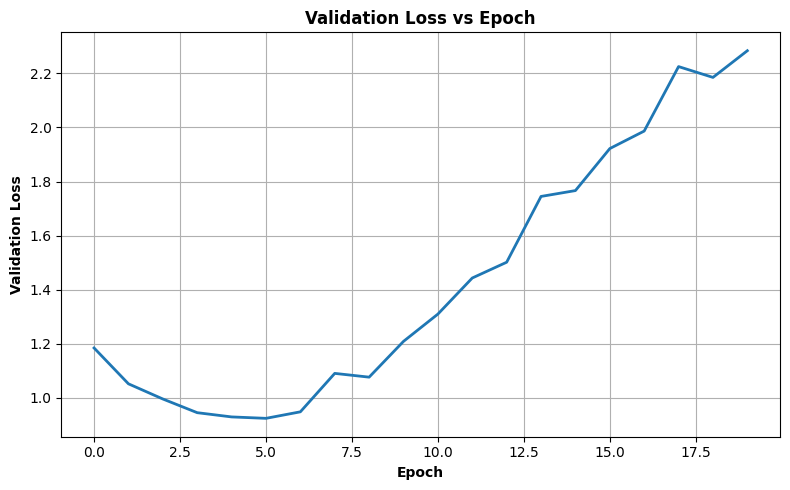

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_loss"],
    linewidth=2
)

plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Validation Loss", fontweight="bold")
plt.title("Validation Loss vs Epoch", fontweight="bold")

plt.grid(True)
plt.tight_layout()
plt.show()

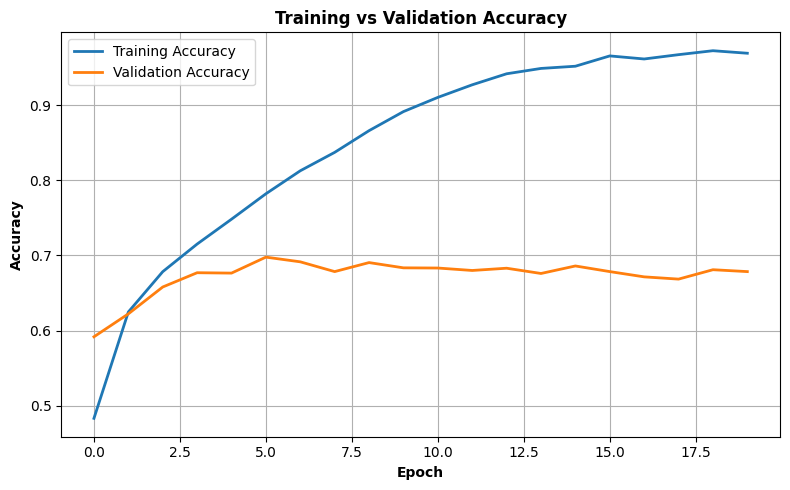

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Accuracy", fontweight="bold")
plt.title(
    "Training vs Validation Accuracy",
    fontweight="bold"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

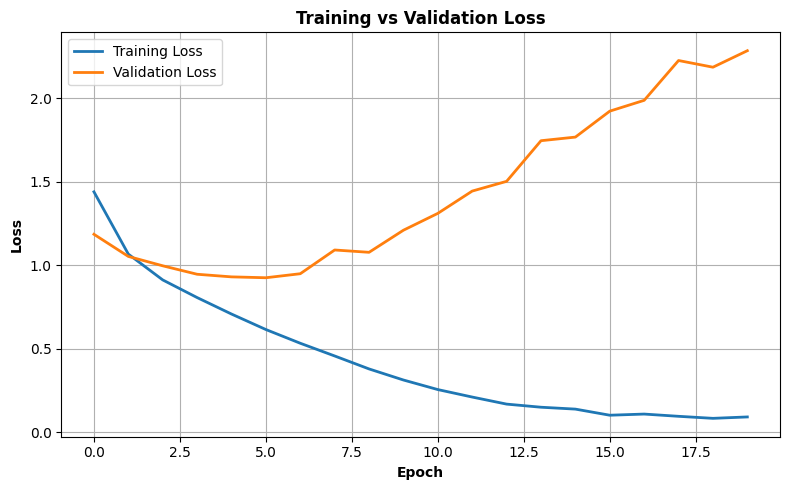

In [67]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Loss", fontweight="bold")
plt.title(
    "Training vs Validation Loss",
    fontweight="bold"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Additional

In [68]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    AveragePooling2D,
    Flatten,
    Dense
)

avg_model = Sequential([

    Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    AveragePooling2D(
        pool_size=(2, 2)
    ),

    Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    AveragePooling2D(
        pool_size=(2, 2)
    ),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        10,
        activation="softmax"
    )
])

c:\Users\karet\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
avg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 16, 16, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 8, 8, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
avg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [71]:
avg_history = avg_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4467 - loss: 1.5399 - val_accuracy: 0.5460 - val_loss: 1.2890
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5787 - loss: 1.1875 - val_accuracy: 0.6050 - val_loss: 1.1271
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.6366 - loss: 1.0278 - val_accuracy: 0.6263 - val_loss: 1.0841
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.6772 - loss: 0.9234 - val_accuracy: 0.6603 - val_loss: 0.9843
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.7005 - loss: 0.8455 - val_accuracy: 0.6862 - val_loss: 0.9362
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.7264 - loss: 0.7822 - val_accuracy: 0.6865 - val_loss: 0.9169
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.7491 - loss: 0.7188 - val_accuracy: 0.6915 - val_loss: 0.9205
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.7692 -

In [72]:
avg_test_loss, avg_test_accuracy = avg_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Average Pooling Test Loss     :", avg_test_loss)
print("Average Pooling Test Accuracy :", avg_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6759 - loss: 1.5432
Average Pooling Test Loss     : 1.5432026386260986
Average Pooling Test Accuracy : 0.6758999824523926


In [73]:
test_loss
test_accuracy

0.6703000068664551

In [74]:
print("\n--- Pooling Comparison ---")

print(
    f"Max Pooling Accuracy     : "
    f"{test_accuracy:.4f}"
)

print(
    f"Average Pooling Accuracy : "
    f"{avg_test_accuracy:.4f}"
)


--- Pooling Comparison ---
Max Pooling Accuracy     : 0.6703
Average Pooling Accuracy : 0.6759


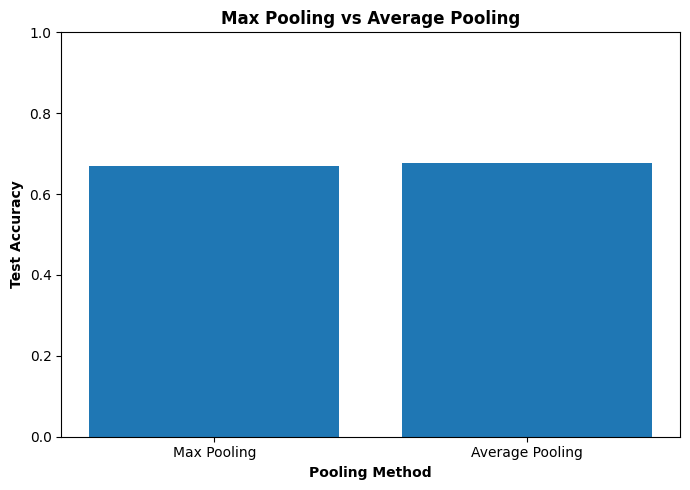

In [75]:
pooling_methods = [
    "Max Pooling",
    "Average Pooling"
]

pooling_accuracy = [
    test_accuracy,
    avg_test_accuracy
]

plt.figure(figsize=(7, 5))

plt.bar(
    pooling_methods,
    pooling_accuracy
)

plt.xlabel(
    "Pooling Method",
    fontweight="bold"
)

plt.ylabel(
    "Test Accuracy",
    fontweight="bold"
)

plt.title(
    "Max Pooling vs Average Pooling",
    fontweight="bold"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [76]:
import time

In [77]:
model_16 = tf.keras.Sequential([
    
    tf.keras.layers.Conv2D(
        16,
        (3, 3),
        padding="same",
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Conv2D(
        16,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

In [78]:
model_16.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [79]:
start_time_16 = time.time()

history_16 = model_16.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

end_time_16 = time.time()

training_time_16 = end_time_16 - start_time_16

print(
    f"16-filter training time: "
    f"{training_time_16:.2f} seconds"
)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4415 - loss: 1.5542 - val_accuracy: 0.5477 - val_loss: 1.2888
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5648 - loss: 1.2312 - val_accuracy: 0.5642 - val_loss: 1.2392
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6104 - loss: 1.1035 - val_accuracy: 0.6152 - val_loss: 1.0982
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6398 - loss: 1.0171 - val_accuracy: 0.6248 - val_loss: 1.0641
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6665 - loss: 0.9468 - val_accuracy: 0.6503 - val_loss: 1.0304
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6919 - loss: 0.8752 - val_accuracy: 0.6575 - val_loss: 1.0041
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7127 - loss: 0.8197 - val_accuracy: 0.6520 - val_loss: 1.0201
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7312 - loss: 0.7679 -

In [80]:
loss_16, accuracy_16 = model_16.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"16-filter test accuracy: {accuracy_16:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6348 - loss: 1.5165
16-filter test accuracy: 0.6348


In [81]:
model_64 = tf.keras.Sequential([
    
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

In [82]:
model_64.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [83]:
start_time_64 = time.time()

history_64 = model_64.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

end_time_64 = time.time()

training_time_64 = end_time_64 - start_time_64

print(
    f"64-filter training time: "
    f"{training_time_64:.2f} seconds"
)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.4775 - loss: 1.4556 - val_accuracy: 0.6035 - val_loss: 1.1493
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.6268 - loss: 1.0578 - val_accuracy: 0.6580 - val_loss: 1.0076
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.6841 - loss: 0.9030 - val_accuracy: 0.6737 - val_loss: 0.9692
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7260 - loss: 0.7978 - val_accuracy: 0.6860 - val_loss: 0.9136
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7541 - loss: 0.7044 - val_accuracy: 0.6795 - val_loss: 0.9466
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7825 - loss: 0.6191 - val_accuracy: 0.7032 - val_loss: 0.9184
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8163 - loss: 0.5285 - val_accuracy: 0.6817 - val_loss: 1.0037
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8439 -

In [84]:
loss_64, accuracy_64 = model_64.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"64-filter test accuracy: {accuracy_64:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6725 - loss: 2.2233
64-filter test accuracy: 0.6725


In [85]:
print("\n========== FILTER COMPARISON ==========")

print(f"16 Filters Accuracy : {accuracy_16:.4f}")
print(f"64 Filters Accuracy : {accuracy_64:.4f}")

print()

print(
    f"16 Filters Time     : "
    f"{training_time_16:.2f} seconds"
)

print(
    f"64 Filters Time     : "
    f"{training_time_64:.2f} seconds"
)


========== FILTER COMPARISON ==========
16 Filters Accuracy : 0.6348
64 Filters Accuracy : 0.6725

16 Filters Time     : 158.04 seconds
64 Filters Time     : 340.12 seconds


In [86]:
print("\n16-filter model parameters:")
model_16.summary()

print("\n64-filter model parameters:")
model_64.summary()


16-filter model parameters:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,776 (1.55 MB)

 Trainable params: 135,258 (528.35 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,693,280 (6.46 MB)

 Trainable params: 564,426 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,128,854 (4.31 MB)

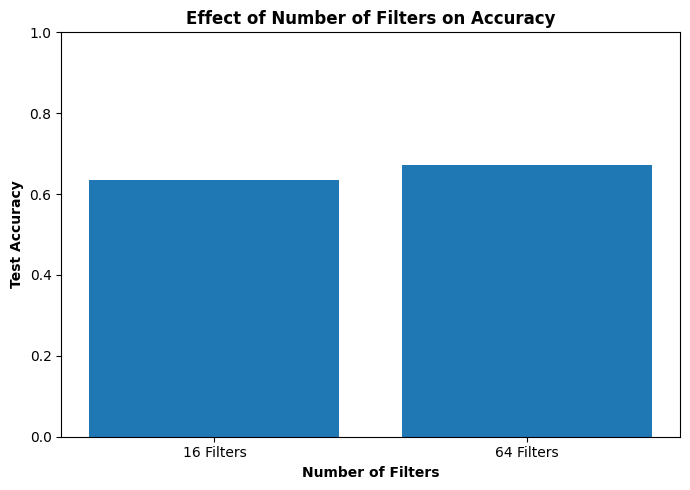

In [87]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["16 Filters", "64 Filters"],
    [accuracy_16, accuracy_64]
)

plt.xlabel(
    "Number of Filters",
    fontweight="bold"
)

plt.ylabel(
    "Test Accuracy",
    fontweight="bold"
)

plt.title(
    "Effect of Number of Filters on Accuracy",
    fontweight="bold"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()